# Classification automatique de réclamations clients 

---

## Contexte 

Une entreprise reçoit un volume important de réclamations textuelles.  
Ce projet entraîne un réseau de neurones capable de les **classifier automatiquement**
en 12 catégories prédéfinies (dataset CFPB — Consumer Financial Protection Bureau).




In [ ]:
import sys
from pathlib import Path

# Ajouter src/ au path (notebooks/ est un niveau sous la racine du projet)
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch
from collections import defaultdict
from IPython.display import Image as IPImage, display as ipy_display

from claims_classifier.config import config
from claims_classifier.utils import set_seed, get_device
from claims_classifier.data.loader import load_raw
from claims_classifier.data.cleaning import run_cleaning, clean_text, LABEL_MAPPING
from claims_classifier.data.dataset import LabelEncoder, make_splits, ClaimsDataset
from claims_classifier.models.textcnn import TextCNN
from claims_classifier.models.mlp import MLP
from claims_classifier.inference.loader import load_for_inference
from claims_classifier.evaluation.metrics import evaluate, check_objective
from claims_classifier.evaluation.reports import plot_confusion_matrix
from torch.utils.data import DataLoader

# Style global
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="muted")

# Reproductibilite 
set_seed(config.training.seed)
device = get_device()
print(f"Seed       : {config.training.seed}")
print(f"Dispositif : {device}")
print(f"PyTorch    : {torch.__version__}")
print("Imports    : OK")


Seed       : 42
Dispositif : cpu
PyTorch    : 2.5.1+cu121
Imports    : OK


---
## Étape 1 — Analyse exploratoire et retraitement

Le dataset contient des réclamations financières anonymisées.  
On analyse la distribution des classes, l’imbalance et on documente toutes les décisions de retraitement.


In [ ]:
# Chargement des donnees brutes 
df_raw = load_raw()
print(f"Shape brut     : {df_raw.shape}")
print(f"Classes brutes : {df_raw['label'].nunique()}")
print()
df_raw.head(3)


Shape brut     : (300000, 2)
Classes brutes : 21



,label,text
0,Credit reporting or other personal consumer re...,"Despite multiple written requests, the unverif..."
1,Checking or savings account,My checking account has been open with Bank of...
2,Vehicle loan or lease,"Hello, My name is XXXX XXXX I am in a 72 month..."


In [3]:
# Pipeline de nettoyage : fusion 21 -> 12 classes + nettoyage texte
df = run_cleaning(df_raw)
counts = df["label"].value_counts()
total = len(df)
n_classes_total = len(counts)

print(f"Observations apres nettoyage : {total:,}")
print(f"Classes finales              : {n_classes_total}")
print()

# Tableau n_i, alpha_i, poids CrossEntropy ponderee
# Formule : weight[i] = n_total / (n_classes x n_i)
print(f"{'Classe':<35} {'n_i':>9} {'alpha_i':>9} {'weight_CE':>10}")
print("-" * 67)
for lbl, n_i in counts.items():
    alpha_i = n_i / total
    weight = total / (n_classes_total * n_i)
    print(f"  {lbl:<33} {n_i:>9,} {alpha_i:>9.4f} {weight:>10.4f}")

ratio = counts.max() / counts.min()
print(f"\nRatio max/min : {ratio:.0f}:1  ->  desequilibre extreme")


144 textes supprimes (vides ou < 3 mots apres nettoyage)


Observations apres nettoyage : 299,856
Classes finales              : 12

Classe                                    n_i   alpha_i  weight_CE
-------------------------------------------------------------------
  credit_reporting                    179,017    0.5970     0.1396
  debt_collection                      39,434    0.1315     0.6337
  credit_card                          24,145    0.0805     1.0349
  mortgage                             17,482    0.0583     1.4294
  checking_or_savings                  14,929    0.0498     1.6738
  student_loan                          6,570    0.0219     3.8033
  money_transfer                        6,401    0.0213     3.9038
  vehicle_loan                          4,743    0.0158     5.2684
  payday_loan                           3,399    0.0113     7.3516
  bank_account_or_service               2,159    0.0072    11.5739
  consumer_loan                         1,390    0.0046    17.9770
  other                                   187    0.000

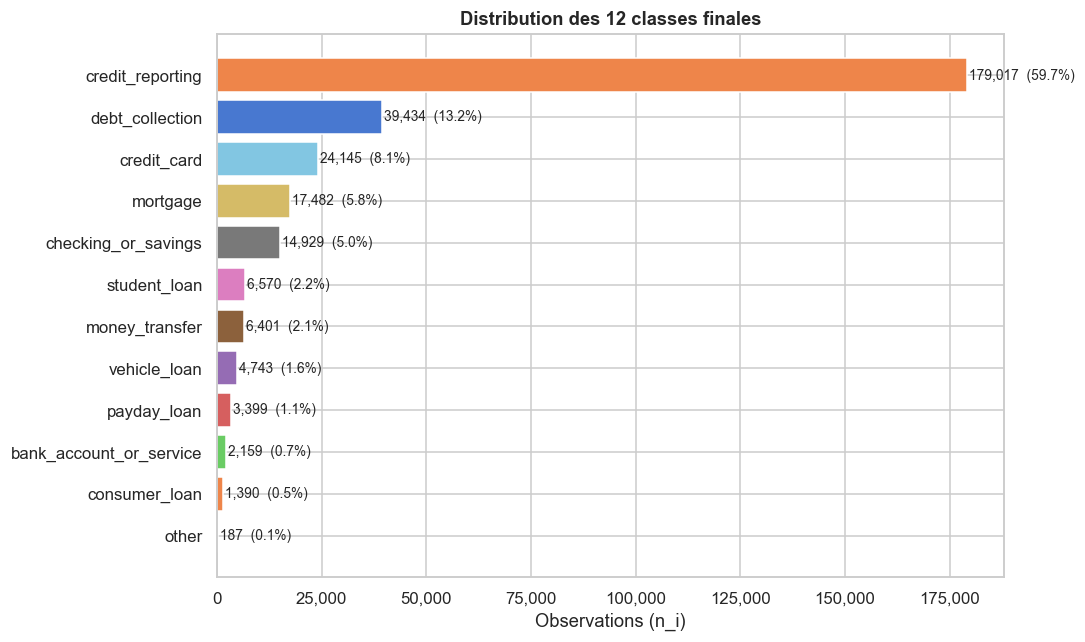

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    counts.index[::-1], counts.values[::-1],
    color=sns.color_palette("muted", len(counts))
)
for bar, val in zip(bars, counts.values[::-1]):
    pct = val / total * 100
    ax.text(
        bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
        f"{val:,}  ({pct:.1f}%)", va="center", fontsize=9
    )
ax.set_xlabel("Observations (n_i)")
ax.set_title("Distribution des 12 classes finales", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


In [5]:
# Fusion 21 -> 12 classes
print("LABEL_MAPPING -- fusion des classes CFPB :")
print("=" * 60)
groups = defaultdict(list)
for brut, final in LABEL_MAPPING.items():
    groups[final].append(brut)

for final_cls, bruts in sorted(groups.items()):
    print(f"\n  {final_cls}")
    for b in bruts:
        marker = "  <- fusionne" if len(bruts) > 1 else ""
        print(f"    <- {b}{marker}")

print()
print("=" * 60)
print("Nettoyage du texte -- exemples :")
print("=" * 60)
examples = [
    "I paid $1,200.50 on XX/XX/2024. My XXXX card was charged twice.",
    "Debt collector called me about XXXX XXXX mortgage on 03/15/XXXX",
]
for raw_ex in examples:
    cleaned_ex = clean_text(raw_ex)
    print(f"  Brut    : {raw_ex}")
    print(f"  Nettoye : {cleaned_ex}")
    print()


LABEL_MAPPING -- fusion des classes CFPB :

  bank_account_or_service
    <- Bank account or service

  checking_or_savings
    <- Checking or savings account

  consumer_loan
    <- Consumer Loan

  credit_card
    <- Credit card or prepaid card  <- fusionne
    <- Credit card  <- fusionne
    <- Prepaid card  <- fusionne

  credit_reporting
    <- Credit reporting, credit repair services, or other personal consumer reports  <- fusionne
    <- Credit reporting or other personal consumer reports  <- fusionne
    <- Credit reporting  <- fusionne

  debt_collection
    <- Debt collection

  money_transfer
    <- Money transfer, virtual currency, or money service  <- fusionne
    <- Money transfers  <- fusionne
    <- Virtual currency  <- fusionne

  mortgage
    <- Mortgage

  other
    <- Debt or credit management  <- fusionne
    <- Other financial service  <- fusionne

  payday_loan
    <- Payday loan, title loan, or personal loan  <- fusionne
    <- Payday loan, title loan, personal 

In [6]:
# Justification max_seq_length = 256 et vocab_size = 30 000
word_counts = df["text"].str.split().str.len()

print("Distribution des longueurs de texte (mots apres nettoyage) :")
for p in [50, 75, 90, 95, 99]:
    q = int(word_counts.quantile(p / 100))
    print(f"  p{p:2d} = {q:5d} mots")

threshold = config.preprocessing.max_seq_length
pct_covered = (word_counts <= threshold).mean() * 100
print(f"\n  max_seq_length = {threshold}  ->  couvre {pct_covered:.1f}% des textes")
print(f"  vocab_size     = {config.preprocessing.vocab_size:,}  ->  top mots freq. du TRAIN uniquement (anti-fuite)")


Distribution des longueurs de texte (mots apres nettoyage) :
  p50 =   103 mots
  p75 =   190 mots
  p90 =   344 mots
  p95 =   494 mots
  p99 =   981 mots

  max_seq_length = 256  ->  couvre 83.5% des textes
  vocab_size     = 30,000  ->  top mots freq. du TRAIN uniquement (anti-fuite)


---
## Étape 2 — Construction du modèle et optimisation

### Architecture retenue : TextCNN 



In [7]:
# Instanciation du modele TextCNN
vocab_size_full = config.preprocessing.vocab_size + 2  # + <pad> + <unk>
model_arch = TextCNN(vocab_size=vocab_size_full, num_classes=12)

print(model_arch)
print(f"\nParametres entrainables : {model_arch.count_parameters():,}")

# Verification passe forward
fake_input = torch.randint(0, vocab_size_full, (2, config.preprocessing.max_seq_length))
with torch.no_grad():
    logits_test = model_arch(fake_input)
print(f"\nPasse forward :")
print(f"  Input  : {fake_input.shape}  (batch=2, seq_len={config.preprocessing.max_seq_length})")
print(f"  Output : {logits_test.shape}       (batch=2, 12 classes)")


TextCNN(
  (embedding): Embedding(30002, 128, padding_idx=0)
  (convolutions): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=384, out_features=12, bias=True)
)

Parametres entrainables : 4,041,868



Passe forward :
  Input  : torch.Size([2, 256])  (batch=2, seq_len=256)
  Output : torch.Size([2, 12])       (batch=2, 12 classes)


In [8]:
# CrossEntropy ponderee -- formule et poids calcules sur le dataset
# (les vrais poids sont calcules sur le TRAIN split uniquement)
print("Formule : weight[i] = n_total / (n_classes x n_i)")
print("Intuition : classe rare -> n_i petit -> poids grand -> erreur amplifiee")
print()
print(f"{'Classe':<35} {'n_i':>9} {'weight[i]':>10}")
print("-" * 57)
for lbl2, n_i2 in counts.items():
    w = total / (n_classes_total * n_i2)
    flag = "  <- tres penalise" if w > 10 else ""
    print(f"  {lbl2:<33} {n_i2:>9,} {w:>10.4f}{flag}")

w_min_ce = total / (n_classes_total * counts.max())
w_max_ce = total / (n_classes_total * counts.min())
print(f"\n  weight_min = {w_min_ce:.4f}  (credit_reporting, classe dominante)")
print(f"  weight_max = {w_max_ce:.2f}  (other, {counts.min()} observations)")
print(f"  Ratio      : {w_max_ce/w_min_ce:.0f}:1  -- compense le desequilibre {counts.max()//counts.min()}:1")


Formule : weight[i] = n_total / (n_classes x n_i)
Intuition : classe rare -> n_i petit -> poids grand -> erreur amplifiee

Classe                                    n_i  weight[i]
---------------------------------------------------------
  credit_reporting                    179,017     0.1396
  debt_collection                      39,434     0.6337
  credit_card                          24,145     1.0349
  mortgage                             17,482     1.4294
  checking_or_savings                  14,929     1.6738
  student_loan                          6,570     3.8033
  money_transfer                        6,401     3.9038
  vehicle_loan                          4,743     5.2684
  payday_loan                           3,399     7.3516
  bank_account_or_service               2,159    11.5739  <- tres penalise
  consumer_loan                         1,390    17.9770  <- tres penalise
  other                                   187   133.6257  <- tres penalise

  weight_min = 0.1396  

Entrainement : TextCNN | 12 epoques | Early stopping (patience=3)
Hardware     : GPU NVIDIA RTX 3090 | ~27s/epoque



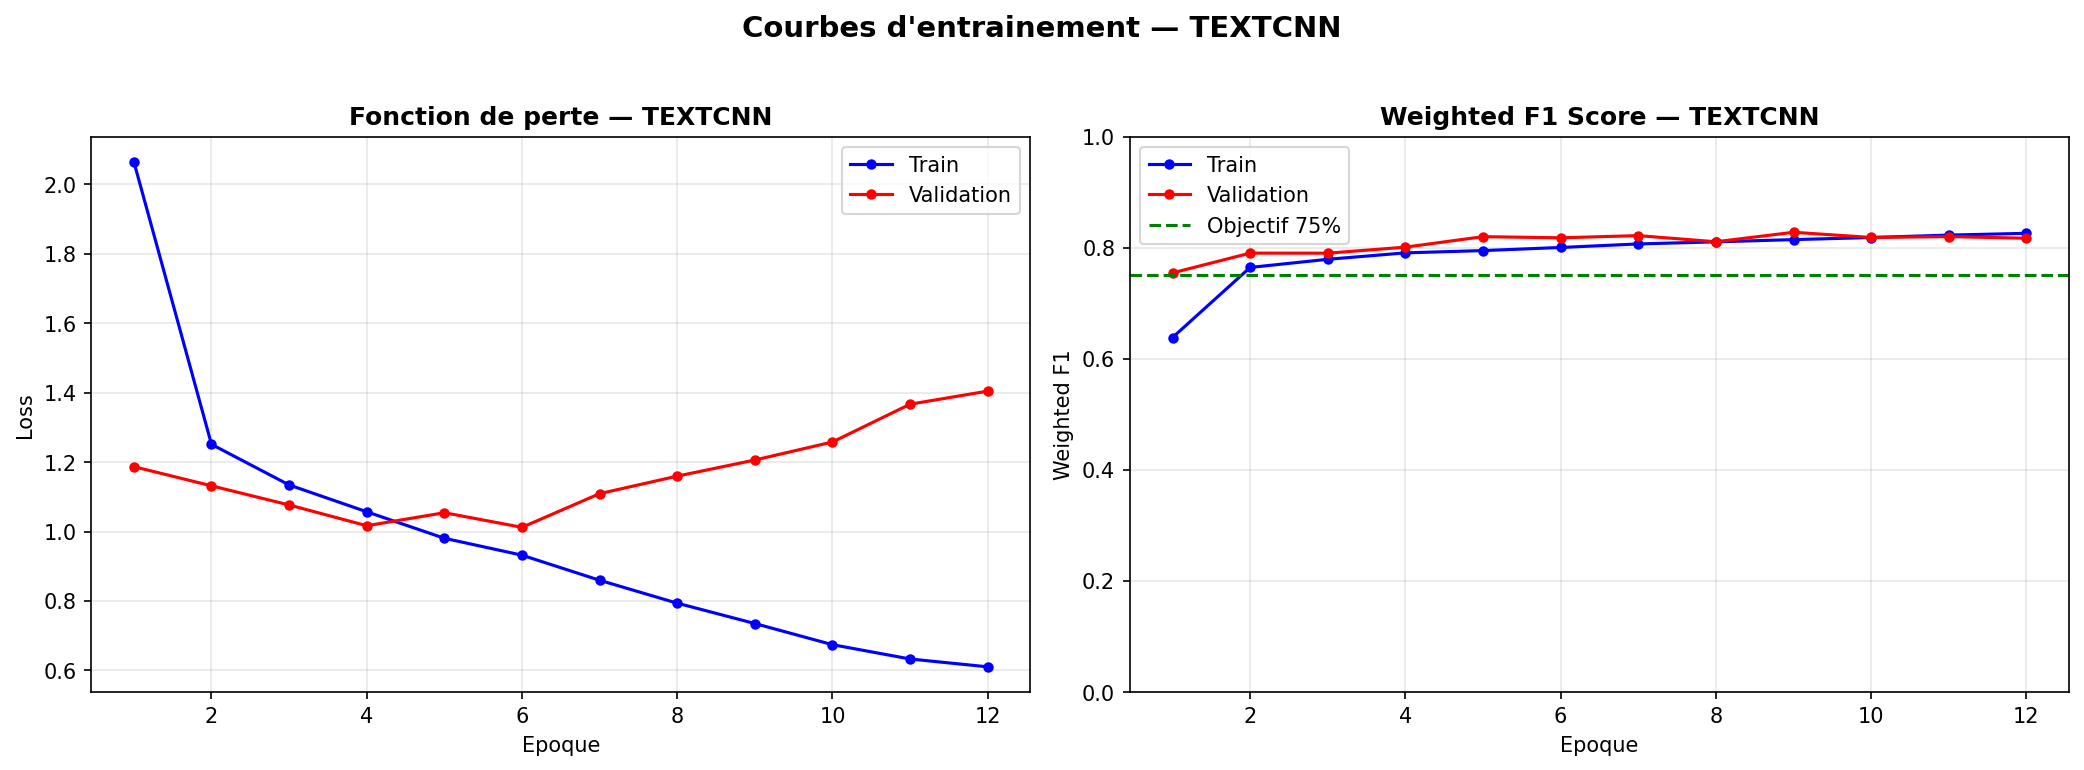

In [9]:
# Courbes d'entrainement -- generees lors de l'entrainement GPU (RTX 3090)
# 12 epoques | early stopping (patience=3) | ~27s/epoque
print("Entrainement : TextCNN | 12 epoques | Early stopping (patience=3)")
print("Hardware     : GPU NVIDIA RTX 3090 | ~27s/epoque")
print()
ipy_display(IPImage("../reports/figures/training_history_textcnn.png", width=950))


---
## Étape 3 — Validation du modèle sur le jeu de test

On charge le meilleur checkpoint (`textcnn_best.pt`) et on évalue
sur le **jeu de test officiel** (44 979 observations, jamais vues pendant l’entraînement).

> Le Weighted F1 est **calculé à l’exécution** 


In [ ]:
# Chargement du checkpoint (weights_only=True -- securite PyTorch)
model_eval, vocab, label_encoder, arch_name, best_val_f1 = load_for_inference()
device_eval = next(model_eval.parameters()).device
print(f"Modele charge : {arch_name.upper()} | Val F1 (best) = {best_val_f1:.4f}")

# Reconstruction du jeu de test -- meme seed=42 
print("\nReconstruction du jeu de test (seed=42)...")
df_eval = load_raw()
df_eval = run_cleaning(df_eval)
_, _, test_df_eval = make_splits(df_eval)
print(f"Jeu de test   : {len(test_df_eval):,} observations")

# DataLoader
test_dataset_eval = ClaimsDataset(test_df_eval, vocab, label_encoder)
test_loader_eval = DataLoader(
    test_dataset_eval,
    batch_size=config.training.batch_size,
    shuffle=False,
    num_workers=config.training.num_workers,
    pin_memory=True,
)

# Evaluation complete sur le jeu de test
print("\nEvaluation en cours (44 979 observations)...")
results = evaluate(model_eval, test_loader_eval, label_encoder, device_eval)
print("Termine.")


Modele charge : TEXTCNN | Val F1 (best) = 0.8276

Reconstruction du jeu de test (seed=42)...


144 textes supprimes (vides ou < 3 mots apres nettoyage)


Jeu de test   : 44,979 observations

Evaluation en cours (44 979 observations)...


Termine.


In [11]:
# Metrique principale -- CALCULEE, jamais codee en dur
wf1 = results.weighted_f1
status = "OBJECTIF ATTEINT (>= 75%)" if wf1 >= 0.75 else "OBJECTIF NON ATTEINT"

print("=" * 60)
print(f"  Weighted F1 Score : {wf1:.4f}  ({wf1*100:.2f}%)")
print(f"  Statut            : {status}")
print(f"  Macro F1          : {results.macro_f1:.4f}  ({results.macro_f1*100:.2f}%)")
print(f"  Accuracy          : {results.accuracy:.4f}  ({results.accuracy*100:.2f}%)")
print("=" * 60)
print()
print("F1 par classe (tri croissant) :")
print(f"  {'Classe':<30} {'F1':>6}")
print("  " + "-" * 40)
for cls_name, f1_val in sorted(results.f1_per_class.items(), key=lambda x: x[1]):
    bar = "#" * int(f1_val * 20)
    flag = "  (!)" if f1_val < 0.5 else ""
    print(f"  {cls_name:<30} {f1_val:.4f}  {bar}{flag}")


  Weighted F1 Score : 0.8312  (83.12%)
  Statut            : OBJECTIF ATTEINT (>= 75%)
  Macro F1          : 0.5935  (59.35%)
  Accuracy          : 0.8230  (82.30%)

F1 par classe (tri croissant) :
  Classe                             F1
  ----------------------------------------
  other                          0.0000    (!)
  consumer_loan                  0.2750  #####  (!)
  bank_account_or_service        0.3795  #######  (!)
  payday_loan                    0.4474  ########  (!)
  vehicle_loan                   0.5390  ##########
  money_transfer                 0.6895  #############
  checking_or_savings            0.7201  ##############
  debt_collection                0.7283  ##############
  credit_card                    0.7453  ##############
  student_loan                   0.8056  ################
  mortgage                       0.8914  #################
  credit_reporting               0.9006  ##################


In [12]:
# Rapport scikit-learn complet
print("Classification Report :")
print("-" * 60)
print(results.report)


Classification Report :
------------------------------------------------------------
                         precision    recall  f1-score   support

bank_account_or_service       0.35      0.41      0.38       324
    checking_or_savings       0.72      0.72      0.72      2239
          consumer_loan       0.24      0.32      0.28       209
            credit_card       0.70      0.80      0.75      3622
       credit_reporting       0.97      0.84      0.90     26853
        debt_collection       0.67      0.80      0.73      5915
         money_transfer       0.60      0.81      0.69       960
               mortgage       0.85      0.94      0.89      2622
                  other       0.00      0.00      0.00        28
            payday_loan       0.41      0.50      0.45       510
           student_loan       0.75      0.87      0.81       986
           vehicle_loan       0.41      0.79      0.54       711

               accuracy                           0.82     44979
   

Matrice sauvegardee : C:\Users\chris\Desktop\claims-classifier\reports\figures\confusion_matrix_textcnn.png



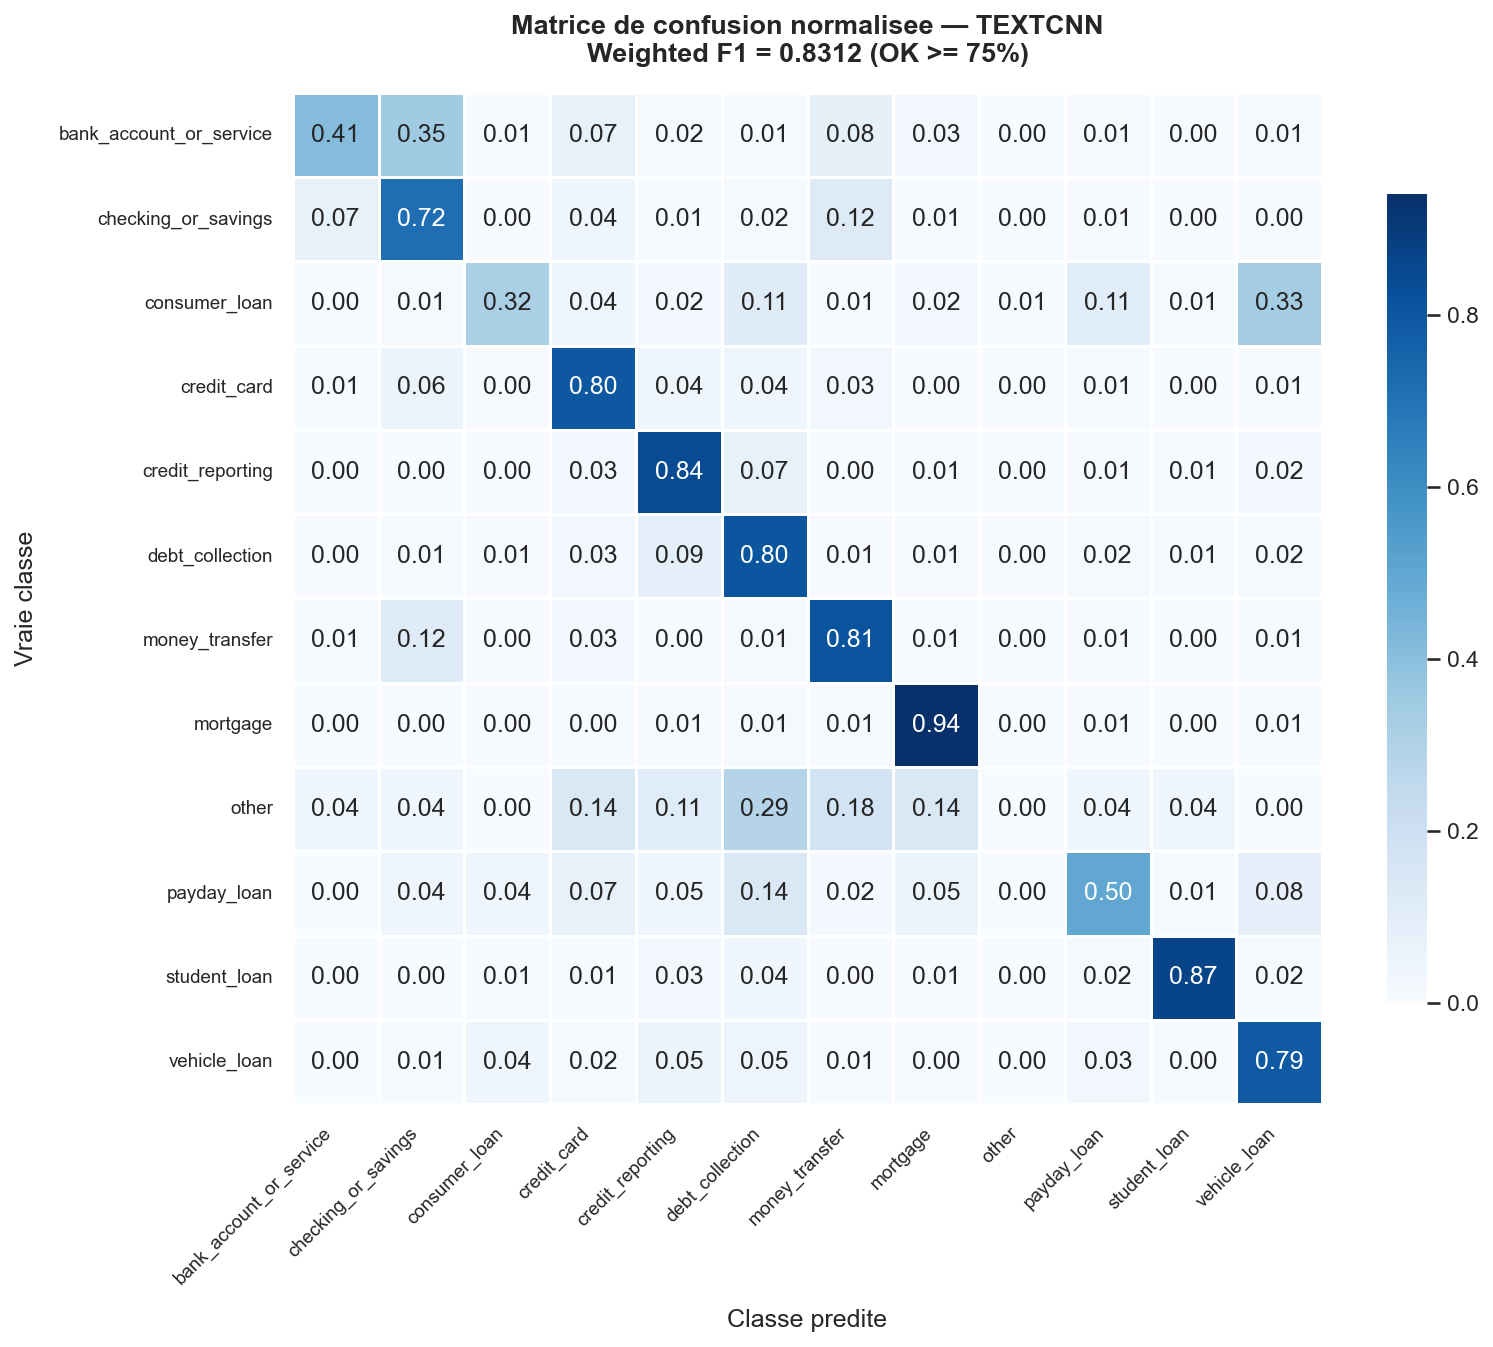

In [13]:
# Regeneration de la matrice de confusion depuis les predictions calculees
cm_path = plot_confusion_matrix(
    results,
    class_names=label_encoder.classes,
    model_name=arch_name,
)
print(f"Matrice sauvegardee : {cm_path}")
print()
ipy_display(IPImage(str(cm_path), width=850))


---
## Conclusion

### Résultats sur le jeu de test

| Modèle | Weighted F1 | Macro F1 | Accuracy | Époques |
|---|---|---|---|---|
| MLP (baseline DL) | **81.16 %** ✅ | 55.15 % | 79.74 % | 7 (early stop) |
| **TextCNN (retenu)** | **83.12 %** ✅ | 59.35 % | 82.30 % | 12 (early stop) |

**Objectif Phase 1 atteint : Weighted F1 ≥ 75 %** ✅

### Pourquoi TextCNN plutôt que MLP ?

- **+2 pts Weighted F1** (83.12 % vs 81.16 %)
- **+4 pts Macro F1** (59.35 % vs 55.15 %) — meilleure généralisation sur les classes minoritaires
- Conv1D détecte les n-grammes caractéristiques de chaque type de réclamation,
  là où le MLP (average pooling) perd l’information positionnelle


